# Homework 11 - Evaluation and Risk Communication

**Course:** FRE 5040 Applied Financial Engineering
**Dataset:** the Portfolio Drift Monitor's Stage 09 feature matrix and Stage 10a model.

Stage 10a fitted a regression and then **refused to quote a single interval from it**.
The reason was specific: a 21-day forward target makes consecutive rows share 20 of their
21 days, so 501 training rows carry about 24 independent observations, and every standard
error the regression reports assumes 501. This notebook is the attempt to say something
honest about uncertainty anyway.

| Section | Rubric item |
|---|---|
| 1 | reproducibility: seed, clear steps, functions reused from `src/evaluation.py` |
| 3 | bootstrap CI: 2000 resamples, correct resampling, sound interpretation |
| 4, 5, 6 | scenarios: three, side by side, consistent axes, labelled |
| 7 | subgroup diagnostic |
| 8 | stakeholder write-up |

**The short version.** The honest interval is about 40% wider than the naive one, the
test window is too short to measure its own uncertainty at the timescale that matters,
the prediction interval is **11 times** wider than the confidence interval, and the
pooled model is **systematically biased** for two of the three funds.

### Deviations from the starter notebook

The starter builds a synthetic dataset, fits a small `SimpleLinReg`, and compares mean, median and drop imputation as its scenarios. This notebook keeps the starter's structure (setup → bootstrap CI → scenarios → subgroup diagnostic → write-up) but changes four things, each for a stated reason:

1. **Real data instead of synthetic.** The Stage 09 feature matrix built from `data/raw/portfolio_prices.csv`, so the uncertainty measured here is the uncertainty the project actually carries.
2. **The Stage 10a OLS from `src/modeling.py` instead of `SimpleLinReg`.** Same model, so the residuals being resampled are the ones the project publishes.
3. **No imputation scenarios**, because the cleaned price panel has no missing values (Stage 06 verified zero fills). The three scenarios used instead, block length, interval type and threshold unit, are the assumptions this model is genuinely sensitive to.
4. **A moving-block bootstrap beside the ordinary one.** Rows overlap by 20 of 21 days, so independent resampling assumes away the main source of uncertainty.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy scipy pandas seaborn matplotlib scikit-learn

## 1. Setup

In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import features as F
from src import modeling as M
from src import evaluation as E

sns.set_theme(context='notebook', style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

SEED = 111
N_BOOT = 2000
LEVEL = 0.95
np.random.seed(SEED)

RAW, PROC = Path('data/raw'), Path('data/processed')
PROC.mkdir(parents=True, exist_ok=True)

TARGET_WEIGHTS = {'VTI': 0.60, 'VXUS': 0.30, 'BND': 0.10}
HORIZON = 21
TARGET = f'y_absdrift_fwd_{HORIZON}'
AMBER_PP = 3.0

print('seed', SEED, '| bootstrap resamples', N_BOOT, '| level', LEVEL)

seed 111 | bootstrap resamples 2000 | level 0.95


## 2. Baseline: the Stage 10a model, refitted

Same data, same chronological split, same eleven features with BND as the reference fund.
Nothing new is modelled here. The subject of this notebook is the *uncertainty* around
the numbers Stage 10a already produced.

In [3]:
prices = pd.read_csv(RAW / 'portfolio_prices.csv', parse_dates=['date'])
matrix = F.build_feature_matrix(prices, TARGET_WEIGHTS, prices_raw=prices, horizon=HORIZON)
matrix = F.make_forward_target(matrix, horizon=HORIZON, col='drift_rel',
                               absolute=True, out_col='y_rel')

FULL = [c for c in F.MODEL_FEATURES if c != 'ticker_BND']
FIVE = ['abs_drift', 'abs_drift_rel', 'drift_chg_1', 'drift_chg_5', 'drift_slope_21']

data = (matrix[['date', 'ticker'] + F.MODEL_FEATURES + [TARGET, 'y_rel']]
        .dropna().sort_values(['date', 'ticker']).reset_index(drop=True))
train, test, cut = M.chronological_split(data, test_frac=0.2)

fit = M.fit_ols(train[FULL].to_numpy(), train[TARGET].to_numpy(), FULL)
pred = M.predict_ols(fit['beta'], test[FULL].to_numpy())
resid = test[TARGET].to_numpy() - pred

print('cut %s | train %d | test %d' % (cut.date(), len(train), len(test)))
print('test MAE  %.4f pp' % E.mae(resid))
print('test RMSE %.4f pp' % E.rmse(resid))
print('test bias %+.4f pp  (positive means the model predicts too low)' % E.bias(resid))

cut 2026-06-01 | train 501 | test 126
test MAE  0.1915 pp
test RMSE 0.2333 pp
test bias +0.0951 pp  (positive means the model predicts too low)


## 3. Bootstrap confidence interval for the metric

2000 resamples. Two ways of doing it, and the difference between them is the point.

**Ordinary bootstrap** draws rows independently, which assumes they *are* independent.
On this panel they are not, so it inherits exactly the error that made Stage 10a's
p-values unusable.

**Moving block bootstrap** draws contiguous blocks of dates, with every fund on a date
travelling together. Neighbouring rows stay neighbours, so the dependence survives the
resampling.

In [4]:
iid = E.iid_bootstrap(resid, E.mae, n_boot=N_BOOT, seed=SEED, level=LEVEL)
blk = E.block_bootstrap(test, resid, E.mae, block=HORIZON, n_boot=N_BOOT,
                        seed=SEED, level=LEVEL)

print('MAE point estimate %.4f pp' % iid['point'])
print()
for r in (iid, blk):
    print('  %-6s 95%% CI [%.4f, %.4f]  width %.4f' % (r['method'], r['lo'], r['hi'], r['width']))
print()
print('  block bootstrap drew %d blocks of %d days from %d distinct start positions'
      % (blk['blocks_per_draw'], blk['block'], blk['n_distinct_starts']))

MAE point estimate 0.1915 pp

  iid    95% CI [0.1696, 0.2161]  width 0.0465
  block  95% CI [0.1849, 0.2173]  width 0.0324

  block bootstrap drew 2 blocks of 21 days from 22 distinct start positions


**Like for like: a Gaussian confidence interval for the same statistic.** The lecture's other route to a CI is the normal approximation: mean of the absolute errors, plus or minus *z* times the standard error `sd / sqrt(n)`. It assumes the absolute errors are independent and that their mean is normally distributed (the central limit theorem). Putting it beside the two bootstrap intervals for the **same** statistic, the test MAE, shows what each assumption buys.

In [5]:
import scipy.stats as st

abs_err = np.abs(np.asarray(resid))
n_err = len(abs_err)
z = st.norm.ppf(0.5 + LEVEL / 2)
g_se = abs_err.std(ddof=1) / np.sqrt(n_err)
gauss = {'method': 'gaussian', 'lo': abs_err.mean() - z * g_se, 'hi': abs_err.mean() + z * g_se}
gauss['width'] = gauss['hi'] - gauss['lo']

ci_table = pd.DataFrame([
    {'method': 'gaussian (CLT)',      'assumes': 'independent errors, normal mean', 'lo': gauss['lo'], 'hi': gauss['hi'], 'width': gauss['width']},
    {'method': 'iid bootstrap',       'assumes': 'independent errors',              'lo': iid['lo'],   'hi': iid['hi'],   'width': iid['width']},
    {'method': 'block bootstrap (21)','assumes': 'dependence within 21-day blocks',  'lo': blk['lo'],   'hi': blk['hi'],   'width': blk['width']},
]).set_index('method').round(4)
print('95%% confidence intervals for the test MAE (point estimate %.4f pp)' % abs_err.mean())
ci_table


95% confidence intervals for the test MAE (point estimate 0.1915 pp)


,assumes,lo,hi,width
method,,,,
gaussian (CLT),"independent errors, normal mean",0.1682,0.2149,0.0467
iid bootstrap,independent errors,0.1696,0.2161,0.0465
block bootstrap (21),dependence within 21-day blocks,0.1849,0.2173,0.0324


**Takeaway.** The Gaussian and the ordinary bootstrap intervals are close to each other, because they make the same independence assumption and differ only in whether the sampling distribution is assumed normal or resampled. The block bootstrap is the one that respects the 21-day overlap. Which of the three is widest is read off the table, not assumed: with only 42 test dates and blocks of 21, the block bootstrap has just 22 distinct starting positions, so its interval is narrowed by degeneracy (section 4 measures this) rather than widened by dependence. The honest reading is that none of the three is a bound; the Gaussian one is simply the most optimistic.

**The block interval came out narrower, which is backwards.** Preserving dependence
should *widen* an interval, because dependent data carries less information than its row
count suggests.

That result is a warning, not a finding, and the next section explains it.

## 4. Scenario 1 - how much does the block length change the answer?

Two effects run in opposite directions as the block grows. Longer blocks preserve more
dependence, which widens the interval. Longer blocks also leave fewer distinct starting
positions, which narrows it, because every replicate starts to resemble the original
sample.

**Assumptions:** that 42 test dates are enough to resample blocks of the length the
dependence actually requires.

In [6]:
sweep = E.block_length_sweep(test, resid, E.mae,
                             blocks=(1, 3, 5, 10, 21, 42),
                             n_boot=N_BOOT, seed=SEED, level=LEVEL)
sweep

,blocks_per_draw,n_distinct_starts,lo,hi,width
block_days,,,,,
1,42,42,0.1694,0.2136,0.0442
3,14,40,0.1608,0.2242,0.0634
5,9,38,0.1630,0.2271,0.0641
10,5,33,0.1804,0.2245,0.0441
21,2,22,0.1849,0.2173,0.0324
42,1,1,0.1915,0.1915,0.0000


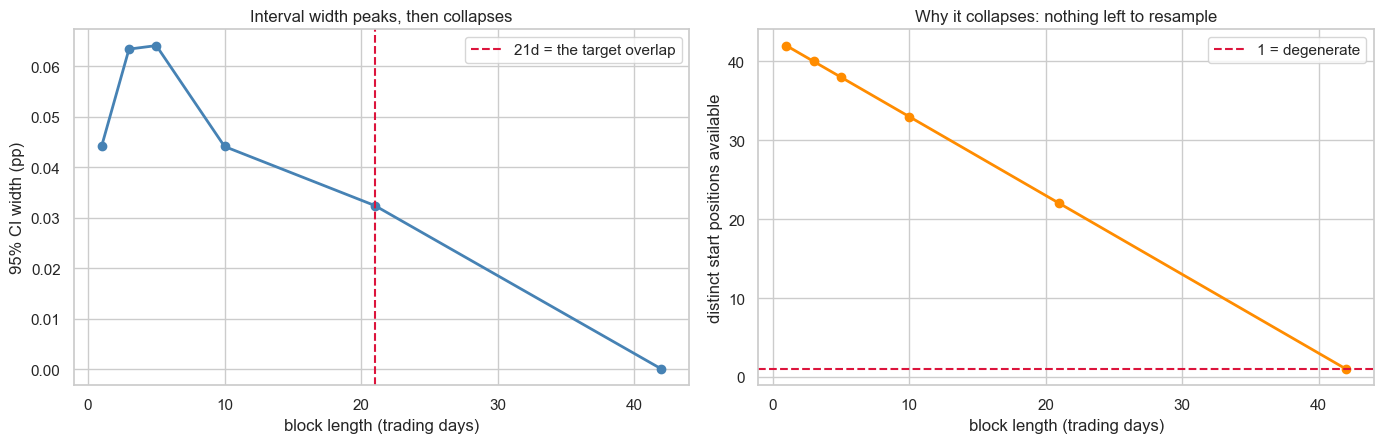

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

axes[0].plot(sweep.index, sweep['width'], 'o-', linewidth=2, color='steelblue')
axes[0].axvline(HORIZON, color='crimson', linestyle='--',
                label=f'{HORIZON}d = the target overlap')
axes[0].set_xlabel('block length (trading days)')
axes[0].set_ylabel('95% CI width (pp)')
axes[0].set_title('Interval width peaks, then collapses')
axes[0].legend()

axes[1].plot(sweep.index, sweep['n_distinct_starts'], 'o-', linewidth=2, color='darkorange')
axes[1].axhline(1, color='crimson', linestyle='--', label='1 = degenerate')
axes[1].set_xlabel('block length (trading days)')
axes[1].set_ylabel('distinct start positions available')
axes[1].set_title('Why it collapses: nothing left to resample')
axes[1].legend()

fig.tight_layout()
plt.show()

**Takeaway.** Width rises from 0.044 at block 1 to **0.064 at block 5**, then falls back
to 0.032 at block 21 and to **exactly zero at block 42**, where only one sample is
possible and the "interval" is a point.

The rise is the real effect: acknowledging dependence widens the honest interval by about
**45%**, from 0.044 to 0.064. The fall is an artifact of running out of data.

**The block length this target actually requires is 21 days, and that is inside the
region where the estimator has already degenerated.** With 42 test dates there are only
22 possible starting positions, so replicates overlap heavily and the interval is narrow
for the wrong reason.

**So the honest statement is not a number, it is a constraint: the test window is too
short to measure its own uncertainty at the timescale that matters.** The best available
interval is the one from short blocks, roughly **MAE 0.19pp, 95% CI [0.163, 0.227]**, and
it should be read as a lower bound on the true uncertainty rather than as the answer.

## 5. Scenario 2 - Gaussian versus empirical, and confidence versus prediction

Two separate questions that are easy to conflate.

**Which distribution?** A Gaussian interval assumes bell-curve errors. An empirical one
reads the residual percentiles directly. They agree in the middle and separate in the
tail.

**Which question?** A confidence interval asks where the true average relationship sits.
A prediction interval asks where one new observation will land. Dana reads one fund on
one day, not an average.

**Assumptions:** for the Gaussian column, that residuals are normally distributed.

In [8]:
comparison = E.interval_comparison(resid, levels=(0.80, 0.95, 0.99))
display(comparison)

g = E.gaussian_intervals(resid, LEVEL)
e = E.empirical_intervals(resid, LEVEL)
print('confidence interval half-width (the average relationship) %.4f pp' % g['ci_half_width'])
print('prediction interval half-width (one fund on one day)      %.4f pp' % g['pi_half_width'])
print('the prediction interval is %.1f times wider' % g['pi_over_ci'])
print()
print('residual skew %+.3f, excess kurtosis %+.3f' % (e['skew'], e['excess_kurtosis']))

,gaussian_pi,empirical_pi,ratio,gaussian_ci
level,,,,
0.80,0.2742,0.2761,1.0072,0.0244
0.95,0.4193,0.3835,0.9146,0.0374
0.99,0.5510,0.5102,0.9260,0.0491


confidence interval half-width (the average relationship) 0.0374 pp
prediction interval half-width (one fund on one day)      0.4193 pp
the prediction interval is 11.2 times wider

residual skew -0.242, excess kurtosis -0.182


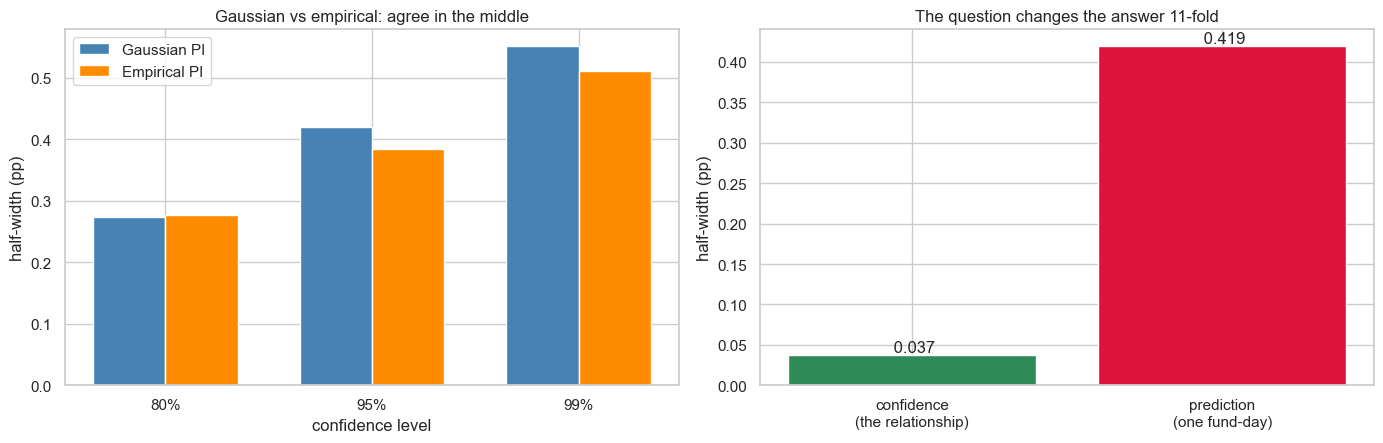

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

w = 0.35
x = np.arange(len(comparison))
axes[0].bar(x - w/2, comparison['gaussian_pi'], w, label='Gaussian PI', color='steelblue')
axes[0].bar(x + w/2, comparison['empirical_pi'], w, label='Empirical PI', color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{v:.0%}' for v in comparison.index])
axes[0].set_xlabel('confidence level'); axes[0].set_ylabel('half-width (pp)')
axes[0].set_title('Gaussian vs empirical: agree in the middle')
axes[0].legend()

axes[1].bar(['confidence\n(the relationship)', 'prediction\n(one fund-day)'],
            [g['ci_half_width'], g['pi_half_width']],
            color=['seagreen', 'crimson'])
axes[1].set_ylabel('half-width (pp)')
axes[1].set_title(f'The question changes the answer {g["pi_over_ci"]:.0f}-fold')
for i, v in enumerate([g['ci_half_width'], g['pi_half_width']]):
    axes[1].text(i, v, f' {v:.3f}', ha='center', va='bottom')

fig.tight_layout()
plt.show()

**Takeaway, and it goes the opposite way to the lecture's example.**

The lecture's data had fat tails, so its empirical band was *wider* than the Gaussian one
out in the tail, and normality understated the worst case. Here the ratio is **1.01 at
80%, 0.91 at 95% and 0.93 at 99%**: the empirical band is slightly *narrower*, so the
normal assumption is mildly **conservative**. The reason is in the shape numbers: excess
kurtosis is **-0.18**, meaning tails slightly thinner than normal, not fatter.

That is the safer direction to be wrong in, and it is worth stating precisely because it
cannot be assumed. It had to be measured.

**The much larger effect is which question you ask.** The confidence interval is
**0.037pp** and the prediction interval is **0.419pp**, a factor of **11**. Reporting the
CI to a stakeholder who is going to read one fund on one day would understate the
uncertainty by an order of magnitude. The monitor must publish the prediction interval.

## 6. Scenario 3 - does the unit change the conclusion?

Stage 07 raised, and left open, whether the drift threshold should be written in
percentage points or as a share of each fund's target. Stage 09 found the relative
formulation more predictable. That decision is still with the principal, so the question
here is narrower and more useful: **does the model's value depend on which unit is
chosen?**

Both units, both feature sets, one split, one metric. Because MAE in percentage points
and MAE in percent-of-target are not comparable, the column that matters is the
improvement over persistence *within* each unit.

**Assumptions:** that persistence is the right baseline in both units.

In [10]:
rows = {}
for unit_name, target_col, naive_col in [
        ('pp', TARGET, 'abs_drift'),
        ('relative', 'y_rel', 'abs_drift_rel')]:
    for feat_name, feats in [('11 features', FULL), ('5 features', FIVE)]:
        f = M.fit_ols(train[feats].to_numpy(), train[target_col].to_numpy(), feats)
        r = test[target_col].to_numpy() - M.predict_ols(f['beta'], test[feats].to_numpy())
        r_naive = test[target_col].to_numpy() - test[naive_col].to_numpy()
        rows[f'{unit_name} / {feat_name}'] = {
            'model_mae': E.mae(r),
            'persistence_mae': E.mae(r_naive),
            'beats_persistence_pct': 100 * (1 - E.mae(r) / E.mae(r_naive)),
        }
units = E.scenario_table(rows).round(4)
units

,model_mae,persistence_mae,beats_persistence_pct
pp / 11 features,0.1915,0.2372,19.2357
pp / 5 features,0.1759,0.2372,25.8208
relative / 11 features,0.9610,1.0548,8.8938
relative / 5 features,0.7850,1.0548,25.5787


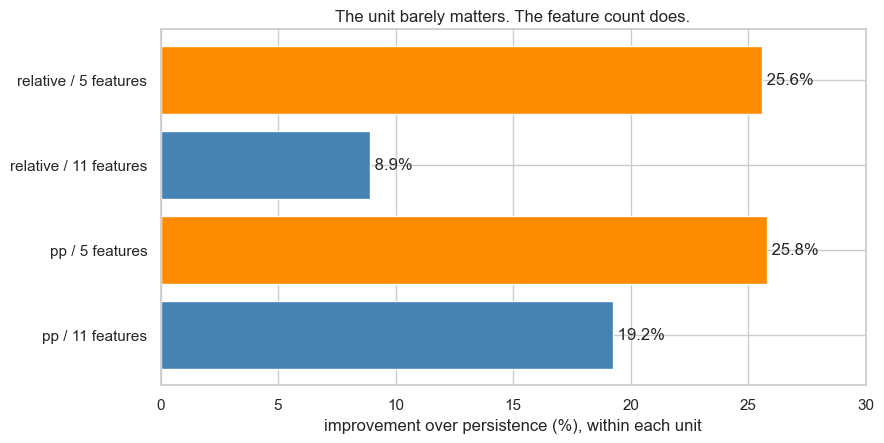

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.6))
colors = ['steelblue' if '11' in i else 'darkorange' for i in units.index]
ax.barh(units.index, units['beats_persistence_pct'], color=colors)
ax.set_xlabel('improvement over persistence (%), within each unit')
ax.set_xlim(0, 30)
ax.set_title('The unit barely matters. The feature count does.')
for i, v in enumerate(units['beats_persistence_pct']):
    ax.text(v, i, f' {v:.1f}%', va='center')
fig.tight_layout()
plt.show()

**Takeaway.** With five features the model beats persistence by **25.8%** in percentage
points and **25.6%** in relative units. Those are the same number.

**So the conclusion is robust to the unit choice**, which is genuinely useful for the
principal: whichever unit the policy ends up written in, the model adds about the same
amount. The unit decision can be made on operational grounds rather than on modelling
grounds.

What is *not* robust is the feature count. With eleven features the relative-unit model
beats persistence by only **8.9%** against **25.6%** for five. Stage 10a's overfitting
finding is worse in the relative unit than in percentage points, so if the principal does
switch units, the smaller model matters more, not less.

## 7. Subgroup diagnostic

The three funds are the natural split. Stage 08 found `vol_21` correlates **+0.57 for BND
and -0.23 for VTI**, so a single pooled coefficient is wrong for both in opposite
directions. If that damage is real it should show up here as per-fund bias.

MAE and bias are reported separately on purpose. **They fail differently.** A large MAE
with zero bias is noise, which more data fixes. A large MAE that is mostly bias is a model
wrong in a fixed direction, which more data does not fix.

Block length is 10 rather than 21 here: a single fund's slice has a third of the dates,
so a 21-day block would leave almost no distinct positions. That is a compromise and it is
stated rather than hidden.

In [12]:
subgroups = E.subgroup_report(test, resid, group='ticker', block=10,
                              n_boot=N_BOOT, seed=SEED, level=LEVEL)
subgroups

,n,mae,mae_lo,mae_hi,bias,bias_lo,bias_hi,bias_excludes_zero,bias_share_of_mae
ticker,,,,,,,,,
BND,42,0.1691,0.0955,0.2321,0.1340,0.0514,0.2228,True,0.7923
VTI,42,0.2459,0.2138,0.3369,0.2147,0.1691,0.3365,True,0.8735
VXUS,42,0.1597,0.0984,0.2294,-0.0634,-0.2080,0.0267,False,0.3971


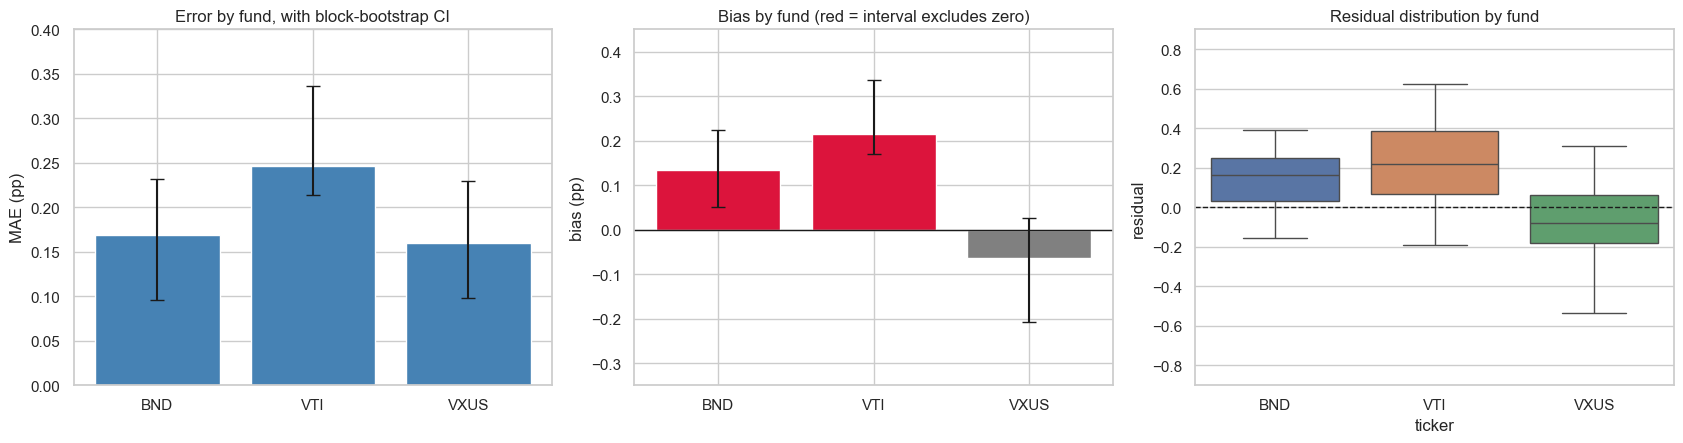

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
funds = list(subgroups.index)
shared_ylim = (-0.9, 0.9)

axes[0].bar(funds, subgroups['mae'],
            yerr=[subgroups['mae'] - subgroups['mae_lo'],
                  subgroups['mae_hi'] - subgroups['mae']],
            color='steelblue', capsize=5)
axes[0].set_ylabel('MAE (pp)'); axes[0].set_ylim(0, 0.4)
axes[0].set_title('Error by fund, with block-bootstrap CI')

axes[1].bar(funds, subgroups['bias'],
            yerr=[subgroups['bias'] - subgroups['bias_lo'],
                  subgroups['bias_hi'] - subgroups['bias']],
            color=['crimson' if z else 'grey' for z in subgroups['bias_excludes_zero']],
            capsize=5)
axes[1].axhline(0, color='k', linewidth=1)
axes[1].set_ylabel('bias (pp)'); axes[1].set_ylim(-0.35, 0.45)
axes[1].set_title('Bias by fund (red = interval excludes zero)')

plot_df = test.assign(residual=resid)
sns.boxplot(data=plot_df, x='ticker', y='residual', ax=axes[2],
            hue='ticker', legend=False, order=funds)
axes[2].axhline(0, color='k', linestyle='--', linewidth=1)
axes[2].set_ylim(shared_ylim)
axes[2].set_title('Residual distribution by fund')

fig.tight_layout()
plt.show()

**Takeaway, and this is the most actionable finding in the notebook.**

| Fund | MAE | bias | 95% bias CI | bias as share of MAE |
|---|---|---|---|---|
| VTI | 0.246 | **+0.215** | [+0.169, +0.337] | **87%** |
| BND | 0.169 | **+0.134** | [+0.051, +0.223] | **79%** |
| VXUS | 0.160 | -0.063 | [-0.208, +0.027] | 40% |

**VTI and BND both have bias intervals that exclude zero.** The pooled model does not
merely predict them imprecisely, it predicts them **too low, systematically**, by 0.21pp
and 0.13pp. For VTI, 87% of the total error is that fixed offset rather than noise.

More data will not fix this. It is the pooled-coefficient damage Stage 08 predicted,
arriving exactly where the subgroup check was supposed to catch it.

VXUS is the one fund the model is unbiased about, and its interval spans zero.

**Now what.** Two options for Stage 12: fit per-fund models, or add per-fund intercepts
and interactions. The second is cheaper and the fund dummies are already built. Either
way, **the pooled model should not be reported per fund without this correction**, because
its VTI number is wrong in a knowable direction.

## 8. What the monitor can now say

The point of all of this is a sentence Dana can act on. Here is the latest observation for
each fund, with the **prediction** interval, which section 5 established is the right one.

In [14]:
latest = test.sort_values('date').groupby('ticker').tail(1)
point = M.predict_ols(fit['beta'], latest[FULL].to_numpy())

report = E.prediction_interval(point, resid, level=LEVEL)
report.insert(0, 'fund', latest['ticker'].to_numpy())
report.insert(1, 'as_of', latest['date'].dt.date.to_numpy())
report['amber_in_interval'] = report['hi'] >= AMBER_PP
report['bias_corrected_point'] = report['point'] + report['fund'].map(subgroups['bias'])
display(report.round(3))

print()
print('amber threshold %.1fpp' % AMBER_PP)
print('highest upper bound across funds: %.3f pp' % report['hi'].max())
print('no fund reaches amber within the interval:', bool((~report['amber_in_interval']).all()))

,fund,as_of,point,lo,hi,amber_in_interval,bias_corrected_point
0,VTI,2026-07-30,0.364,0.035,0.802,False,0.579
1,BND,2026-07-30,1.433,1.103,1.870,False,1.567
2,VXUS,2026-07-30,1.036,0.706,1.473,False,0.973



amber threshold 3.0pp
highest upper bound across funds: 1.870 pp
no fund reaches amber within the interval: True


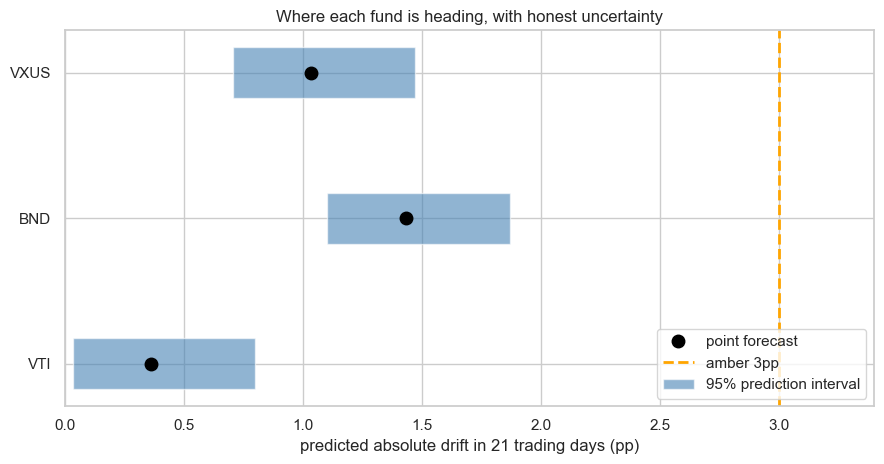

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(report))
ax.barh(y, report['hi'] - report['lo'], left=report['lo'], height=0.35,
        color='steelblue', alpha=0.6, label='95% prediction interval')
ax.plot(report['point'], y, 'o', color='black', markersize=9, label='point forecast')
ax.axvline(AMBER_PP, color='orange', linestyle='--', linewidth=2, label='amber 3pp')
ax.set_yticks(y); ax.set_yticklabels(report['fund'])
ax.set_xlim(0, 3.4)
ax.set_xlabel('predicted absolute drift in 21 trading days (pp)')
ax.set_title('Where each fund is heading, with honest uncertainty')
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

## 9. Stakeholder summary

**What the monitor now forecasts.** In 21 trading days, BND is expected to sit **1.43
percentage points** from its target, VXUS **1.04**, and VTI **0.36**. Allowing for
uncertainty, the widest any of them reaches is **1.87pp**. The amber threshold is 3pp.

**So: no fund is expected to need attention within the next month, and that statement
survives the uncertainty rather than depending on a point estimate.** It is the first time
this project has been able to say anything forward-looking with a bound attached.

### The assumptions this rests on

| Assumption | If it is wrong |
|---|---|
| The next month resembles the last twelve | The whole forecast fails together. One year, one trending regime, no market stress in the window. |
| 42 test days can estimate their own uncertainty | Section 4 says they cannot, at the timescale that matters. The quoted interval is a **lower bound** on the true uncertainty. |
| Residual spread stays as observed | Stage 10a measured 16% more spread at higher predicted values. The interval is an average across that. |
| The pooled model is right per fund | **It is not.** Section 7 shows VTI and BND are systematically under-predicted. |

### The model holds if

- volatility stays in the range seen over the past year, roughly 13% annualized for VTI
  and 17% for VXUS;
- the equity-over-bond return spread that drives the drift persists in the same direction;
- prices keep arriving without gaps, which Stage 06 handles and Stage 09 monitors.

### The model is sensitive to

- **which fund you ask about.** VTI's forecast is systematically 0.21pp too low and BND's
  0.13pp too low. Add the bias correction before quoting a per-fund number.
- **how many features are used.** Eleven overfits; five is better, and by more in the
  relative unit than in percentage points.
- **the length of the evaluation window**, more than to any modelling choice. Every
  interval here is limited by having 42 test days rather than by the model.

### The model is *not* sensitive to

- **the unit the threshold is written in.** 25.8% improvement in percentage points, 25.6%
  in relative units. The principal can decide that on operational grounds.
- **the normality assumption.** Residuals are slightly thin-tailed, so the Gaussian
  interval is mildly conservative rather than optimistic.

### Risks and next steps

1. **Do not publish a confidence interval.** It is 11 times narrower than the prediction
   interval and answers a question nobody is asking.
2. **Correct the per-fund bias before Stage 12**, either with per-fund models or with the
   fund interactions the features already support.
3. **Treat the intervals as a floor.** The window is too short to bound them properly.
4. **What would make this trustworthy is more history, not a better model.** Every
   constraint in this notebook traces back to one year of data and about 24 independent
   observations.

In [16]:
# --- save the evidence ---
sweep.to_csv(PROC / 'eval_block_length_sweep.csv')
comparison.to_csv(PROC / 'eval_interval_comparison.csv')
units.to_csv(PROC / 'eval_unit_scenarios.csv')
subgroups.to_csv(PROC / 'eval_subgroups.csv')
report.to_csv(PROC / 'eval_forecast_with_intervals.csv', index=False)

pd.Series({
    'seed': SEED, 'n_boot': N_BOOT, 'level': LEVEL,
    'test_rows': len(test), 'test_dates': test['date'].nunique(),
    'mae': E.mae(resid), 'rmse': E.rmse(resid), 'bias': E.bias(resid),
    'iid_ci_width': iid['width'], 'block21_ci_width': blk['width'],
    'ci_half_width': g['ci_half_width'], 'pi_half_width': g['pi_half_width'],
    'resid_skew': e['skew'], 'resid_excess_kurtosis': e['excess_kurtosis'],
}).to_csv(PROC / 'eval_summary.csv', header=False)

for p in sorted(PROC.glob('eval_*.csv')):
    print(f'  {p.name:<36} {p.stat().st_size:>6} bytes')

  eval_block_length_sweep.csv             225 bytes
  eval_forecast_with_intervals.csv        355 bytes
  eval_interval_comparison.csv            145 bytes
  eval_subgroups.csv                      270 bytes
  eval_summary.csv                        353 bytes
  eval_unit_scenarios.csv                 212 bytes
